The libraries needed for image processing and graphics generation.

In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from matplotlib.image import imread

# Set directories for training data
data_dir = 'inputs'
train_path = os.path.join(data_dir, 'train')
validation_path = os.path.join(data_dir, 'validation')
test_path = os.path.join(data_dir, 'test')

In [24]:
# Define the correct training dataset path
train_path = '../inputs/train'

# Get all labels (folder names)
labels = os.listdir(train_path)

print(f"Project Labels: {labels}")

Project Labels: ['healthy', 'powdery_mildew']


In [25]:
# Define the correct outputs directory path
output_dir = '../outputs/v1'

# Create the outputs directory if it does not exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Directory '{output_dir}' created successfully!")
else:
    print(f"Directory '{output_dir}' already exists.")

Directory '../outputs/v1' already exists.


Image Size Analysis

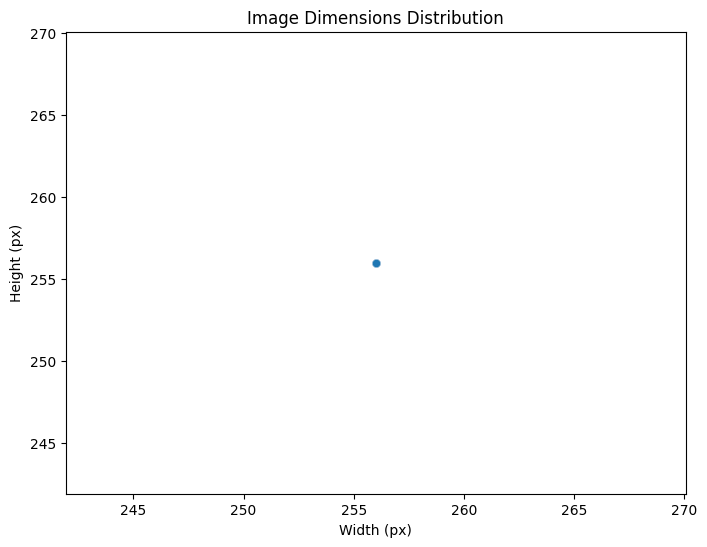

Average Image Shape: (256, 256, 3)


['../outputs/v1/image_shape.pkl']

In [26]:
# Store image dimensions
dim1 = []
dim2 = []

# Loop through all labels and images
for label in labels:

    label_path = os.path.join(train_path, label)

    for image_filename in os.listdir(label_path):

        image_path = os.path.join(label_path, image_filename)

        img = imread(image_path)

        d1, d2, colors = img.shape

        dim1.append(d1)  # Image height
        dim2.append(d2)  # Image width

# Create a scatter plot for image dimensions
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=dim2,
    y=dim1,
    alpha=0.1
)

plt.title('Image Dimensions Distribution')
plt.xlabel('Width (px)')
plt.ylabel('Height (px)')

plt.savefig(
    '../outputs/v1/image_dimensions_distribution.png',
    bbox_inches='tight'
)

plt.show()

# Calculate the average image dimensions
image_shape = (
    int(np.mean(dim1)),
    int(np.mean(dim2)),
    3
)

print(f"Average Image Shape: {image_shape}")

# Save the image shape for future model training
joblib.dump(
    value=image_shape,
    filename='../outputs/v1/image_shape.pkl'
)

Viewing the "Average Image"

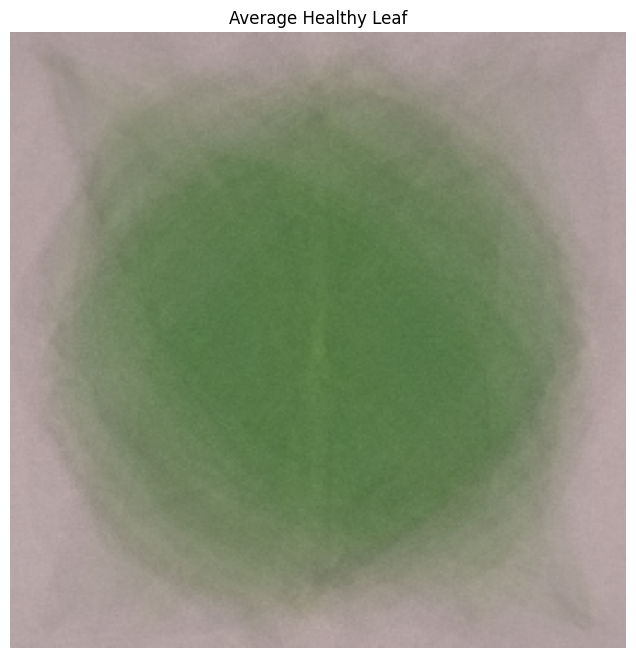

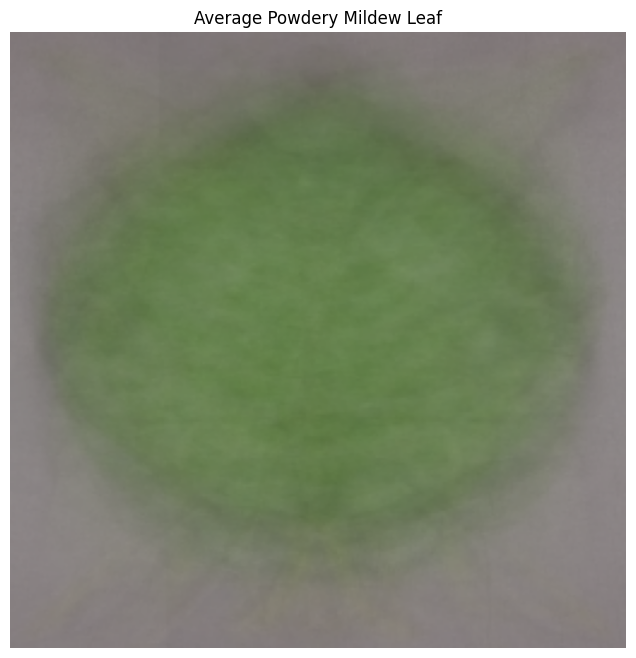

In [27]:
def load_image_as_array(directory, label, n_images=20):
    """
    Load a subset of images from a folder
    and convert them into a NumPy array.
    """

    images = []

    label_path = os.path.join(directory, label)

    if not os.path.exists(label_path):
        raise FileNotFoundError(
            f"Directory not found: {label_path}"
        )

    image_files = os.listdir(label_path)[:n_images]

    for img_file in image_files:

        image_path = os.path.join(label_path, img_file)

        img = imread(image_path)

        images.append(img)

    return np.array(images)


# Generate average images for healthy leaves
avg_healthy = load_image_as_array(
    train_path,
    'healthy',
    n_images=50
).mean(axis=0)


# Generate average images for mildew leaves
avg_mildew = load_image_as_array(
    train_path,
    'powdery_mildew',
    n_images=50
).mean(axis=0)


# Display and save healthy average image
plt.figure(figsize=(8, 8))

plt.imshow(avg_healthy.astype(np.uint8))

plt.title('Average Healthy Leaf')

plt.axis('off')

plt.savefig(
    '../outputs/v1/avg_diff_healthy.png',
    bbox_inches='tight'
)

plt.show()


# Display and save powdery mildew average image
plt.figure(figsize=(8, 8))

plt.imshow(avg_mildew.astype(np.uint8))

plt.title('Average Powdery Mildew Leaf')

plt.axis('off')

plt.savefig(
    '../outputs/v1/avg_diff_powdery_mildew.png',
    bbox_inches='tight'
)

plt.show()

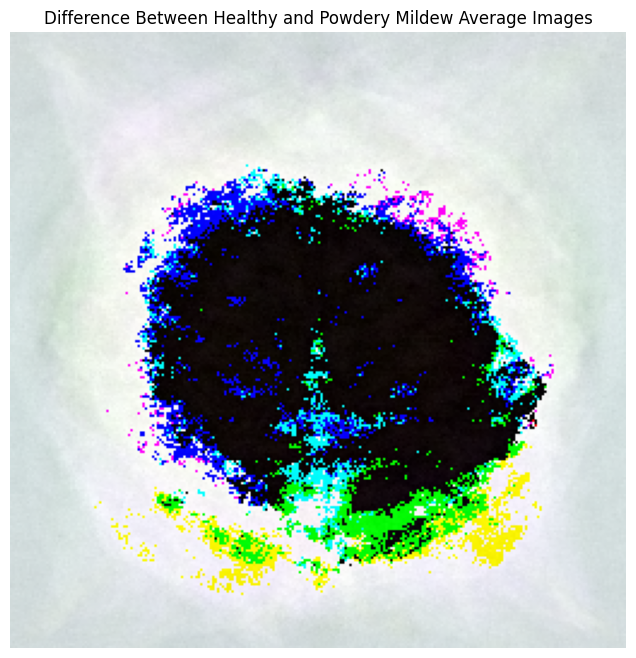

Difference image saved successfully.


In [29]:
# Calculate the difference between the two average images
diff_img = avg_mildew - avg_healthy

# Create figure
plt.figure(figsize=(8, 8))

# Display image
plt.imshow(diff_img.astype(np.uint8))

# Add title
plt.title(
    'Difference Between Healthy and Powdery Mildew Average Images'
)

# Remove axes
plt.axis('off')

# Save the image
plt.savefig(
    '../outputs/v1/avg_diff.png',
    bbox_inches='tight'
)

# Display the figure
plt.show()

print("Difference image saved successfully.")